In [ ]:
import s3fs
fs = s3fs.S3FileSystem(anon=True)
asdf_dir_uri = 's3://stpubdata/roman/nexus/soc_simulations/tutorial_data/roman-2026.2/'
fs.ls(asdf_dir_uri)

['stpubdata/roman/nexus/soc_simulations/tutorial_data/roman-2026.2/Roman_OpticalModel_v0.5.yml',
 'stpubdata/roman/nexus/soc_simulations/tutorial_data/roman-2026.2/full_catalog.ecsv',
 'stpubdata/roman/nexus/soc_simulations/tutorial_data/roman-2026.2/my_roman_mosaic_asn.json',
 'stpubdata/roman/nexus/soc_simulations/tutorial_data/roman-2026.2/my_roman_mosaic_cat.parquet',
 'stpubdata/roman/nexus/soc_simulations/tutorial_data/roman-2026.2/my_roman_mosaic_coadd.asdf',
 'stpubdata/roman/nexus/soc_simulations/tutorial_data/roman-2026.2/my_roman_mosaic_segm.asdf',
 'stpubdata/roman/nexus/soc_simulations/tutorial_data/roman-2026.2/r0003201001001001004_0001_wfi01_f106_cal.asdf',
 'stpubdata/roman/nexus/soc_simulations/tutorial_data/roman-2026.2/r0003201001001001004_0001_wfi01_f106_cat.parquet',
 'stpubdata/roman/nexus/soc_simulations/tutorial_data/roman-2026.2/r0003201001001001004_0001_wfi01_f106_segm.asdf',
 'stpubdata/roman/nexus/soc_simulations/tutorial_data/roman-2026.2/r00032010010010010

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import roman_datamodels as rdm
from astropy.visualization import simple_norm
from astropy.wcs import WCS

# Focal-plane rotation per SCA (derived from MPA_SCA_info table).
# SCAs 3, 6, 9, 12, 15, 18 are not rotated (r=0); all others are r=180.
_SCA_ROTATION = {n: (0 if n % 3 == 0 else 180) for n in range(1, 19)}


def plot_wfi_sca(dm, *, norm=None, title=None, figsize=(9, 8), ax=None,
                 show_channels=True, show_gridlines=True):
    """Plot a Roman WFI SCA image with readout channel and section grid overlay.

    Reads dm.meta.instrument.detector to look up SCA orientation: most SCAs are
    rotated 180° on the focal plane, which reverses the direction of the pixel
    coordinate axes and the readout channel numbering.

    Parameters
    ----------
    dm : roman_datamodels ImageModel
    norm : matplotlib norm, optional
        Defaults to asinh simple_norm(vmin=0.5, vmax=4).
    title : str, optional
        Defaults to 'Roman WFI <DETECTOR>'.
    figsize : tuple
    ax : matplotlib Axes, optional
    show_channels : bool
        Draw 32 thin channel dividers (128 px each) and channel numbers.
    show_gridlines : bool
        Draw 8-section major grid (512 px each) and section labels a–h / A–H.

    Returns
    -------
    fig, ax
    """
    data     = dm.data
    detector = str(dm.meta.instrument.detector).upper()  # 'WFI11'
    sca_num  = int(detector[-2:])                        # 11
    rotated  = _SCA_ROTATION[sca_num] == 180

    if norm is None:
        norm = simple_norm(data, 'asinh', vmin=0.5, vmax=4)
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure

    sc = ax.imshow(data, norm=norm, origin='lower')
    ax.set(
        xlabel='X Science Axis (pixels)',
        ylabel='Y Science Axis (pixels)',
        title=title or f'Roman WFI {detector}',
    )
    plt.colorbar(sc, ax=ax)

    ny, nx = data.shape
    ref_pix = (4096 - nx) // 2   # 4 if cal product stripped reference pixels, else 0

    if show_channels:
        for j in range(1, 32):
            ax.axvline(128 * j - ref_pix, color='white', alpha=0.2, lw=0.5)

    section_locs = [512 * j - ref_pix for j in range(1, 8)]
    if show_gridlines:
        for pos in section_locs:
            ax.axvline(pos, color='white', alpha=0.4, lw=0.8)
            ax.axhline(pos, color='white', alpha=0.4, lw=0.8)

    # Tick marks at section boundaries; axis direction depends on focal-plane rotation
    tick_locs = [0] + section_locs + [nx - 1]
    tick_vals = [ref_pix] + [512 * j for j in range(1, 8)] + [4096 - ref_pix]
    ax.set_xticks(tick_locs)
    ax.set_yticks(tick_locs)
    if rotated:                        # r=180: x runs low→high, y runs high→low
        ax.set_xticklabels(tick_vals)
        ax.set_yticklabels(tick_vals[::-1])
    else:                              # r=0:   x runs high→low, y runs low→high
        ax.set_xticklabels(tick_vals[::-1])
        ax.set_yticklabels(tick_vals)

    col_label_y = ny + (50 if show_channels else 20)
    ax.set_xlim(-0.5, nx + 50)
    ax.set_ylim(-0.5, ny + (110 if show_channels else 60))

    if show_gridlines:
        for i, (rl, cl) in enumerate(zip('abcdefgh', 'ABCDEFGH')):
            mid = 256 + i * 512 - ref_pix
            ax.text(nx + 18, mid, rl, va='center', fontsize=9)
            ax.text(mid, col_label_y, cl, ha='center', fontsize=9)

    if show_channels:
        for i in range(32):
            chan_num = i + 1 if rotated else 32 - i
            ax.text(64 + i * 128 - ref_pix, ny + 70, str(chan_num),
                    ha='center', fontsize=6)

    return fig, ax


root (AsdfObject)
├─asdf_library (Software)
│ ├─author (str): The ASDF Developers
│ ├─homepage (str): http://github.com/asdf-format/asdf
│ ├─name (str): asdf
│ └─version (str): 5.3.1
├─history (AsdfDictNode)
│ └─extensions (AsdfListNode) ...
└─roman (WfiImage) # Level 2 (L2) Calibrated Roman Wide Field Instrument (WFI) Rate Image.
  ├─meta (AsdfDictNode) ...
  ├─data (NDArrayType) # Science Data (DN/s) or (MJy/sr) ...
  ├─dq (NDArrayType) # Data Quality ...
  ├─err (NDArrayType) # Error (DN / s) or (MJy / sr) ...
  ├─var_poisson (NDArrayType) # Poisson Variance (DN^2/s^2) or (MJy^2/sr^2) ...
  ├─chisq (NDArrayType) # Chi-squared of Ramp Fit ...
  ├─dumo (NDArrayType) # Difference Uniform Minus Optimal (DN / s) or (MJy / sr) ...
  ├─amp33 (NDArrayType) # Amplifier 33 Reference Pixel Data (DN) ...
  ├─border_ref_pix_left (NDArrayType) # Left-Edge Border Reference Pixels (DN) ...
  ├─border_ref_pix_right (NDArrayType) # Right-Edge Border Reference Pixels (DN) ...
  ├─border_ref_pix_top (N

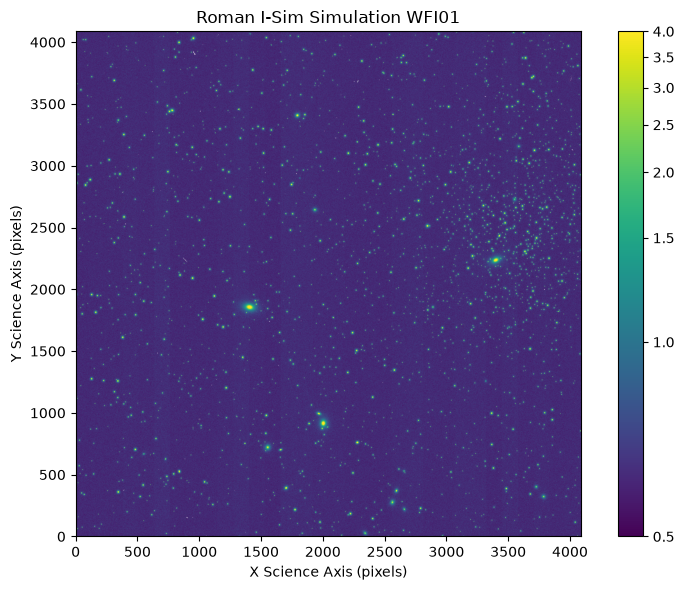

In [ ]:
from astropy.visualization import simple_norm
from astropy.wcs import WCS
import matplotlib.pyplot as plt
import numpy as np

asdf_file_uri = asdf_dir_uri + 'r0003201001001001004_0001_wfi11_f106_cal.asdf'

with fs.open(asdf_file_uri, 'rb') as f:
        dm = rdm.open(f)
        dm.info()
        norm = simple_norm(dm.data, 'asinh', vmin=0.5, vmax=4)

        fig, ax = plt.subplots(figsize=(8, 6))
        sc = ax.imshow(dm.data, norm=norm, origin='lower')
        ax.set(
        xlabel='X Science Axis (pixels)',
        ylabel='Y Science Axis (pixels)',
        title='Roman I-Sim Simulation WFI11'
        )
        plt.colorbar(sc, ax=ax)
        plt.tight_layout();


In [ ]:
asdf_file_uri = asdf_dir_uri + 'r0003201001001001004_0001_wfi11_f106_cal.asdf'

with fs.open(asdf_file_uri, 'rb') as f:
    dm = rdm.open(f)
    fig, ax = plot_wfi_sca(dm)
    plt.tight_layout()


In [ ]:
def MPA_SCA_info(MPA_pos):
    return {
            1  : {'x' : -22.1400,  'y' : 12.1500,  'r' : 180},
            2  : {'x' : -22.2900,  'y' : -37.0300, 'r' : 180},
            3  : {'x' : -22.4400,  'y' : -82.0600, 'r' : 0},
            4  : {'x' : -66.4200,  'y' : 20.9000,  'r' : 180},
            5  : {'x' : -66.9200,  'y' : -28.2800, 'r' : 180},
            6  : {'x' : -67.4200,  'y' : -73.0600, 'r' : 0},
            7  : {'x' : -110.7000, 'y' : 42.2000,  'r' : 180},
            8  : {'x' : -111.4800, 'y' : -6.9800,  'r' : 180},
            9  : {'x' : -112.6400, 'y' : -51.0600, 'r' : 0},
            10 : {'x' : 22.1400,   'y' : 12.1500,  'r' : 180},
            11 : {'x' : 22.2900,   'y' : -37.0300, 'r' : 180},
            12 : {'x' : 22.4400,   'y' : -82.0600, 'r' : 0},
            13 : {'x' : 66.4200,   'y' : 20.9000,  'r' : 180},
            14 : {'x' : 66.9200,   'y' : -28.2800, 'r' : 180},
            15 : {'x' : 67.4200,   'y' : -73.0600, 'r' : 0},
            16 : {'x' : 110.7000,  'y' : 42.2000,  'r' : 180},
            17 : {'x' : 111.4800,  'y' : -6.9800,  'r' : 180},
            18 : {'x' : 112.6400,  'y' : -51.0600, 'r' : 0},
            }[MPA_pos]
